# Legal Entity Extraction Deep-Dive Analysis
### Micro-Level Legal NLP, Co-Occurrence Mining & Structural Layout Analytics

This notebook provides an in-depth analytical deep-dive into the **2,889,841 extracted legal entities** across **38,235 Supreme Court of India judgments**.

#### Analysis Dimensions:
1. **Statutory & Provision Hierarchy**: Section-to-Act linkages under IPC, CrPC, CPC & Constitution.
2. **Provision Co-Occurrence Networks**: Mining statute & section co-citations in the same judgment.
3. **Paragraph Structural Layout**: Positional analysis of entity types (Intro vs Body vs Concluding Orders).
4. **Authority & Precedent Metrics**: Reporter Citations and Bench Size correlation.
5. **Extraction Quality & Confidence Audit**: Confidence quantiles across entity classes.

In [1]:
import os
import duckdb
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Data Paths
DATA_DIR = os.path.abspath('../data/supreme_court/parquet')
META_PATH = os.path.join(DATA_DIR, 'metadata.parquet')
ENTITIES_PATH = os.path.join(DATA_DIR, 'entities.parquet')

con = duckdb.connect(database=':memory:')
con.execute(f"CREATE VIEW metadata AS SELECT * FROM '{META_PATH}'")
con.execute(f"CREATE VIEW entities AS SELECT * FROM '{ENTITIES_PATH}'")

print('DuckDB Connection initialized and views registered successfully!')
print(f"Entities Total Record Count: {con.execute('SELECT COUNT(*) FROM entities').fetchone()[0]:,}")

DuckDB Connection initialized and views registered successfully!
Entities Total Record Count: 2,889,841


## 1. Statutory & Legislative Provision Breakdown
Auditing Bare Act normalization and section breakdowns under major statutory codes.

In [3]:
# Top 15 Bare Acts / Statutes
statutes_df = con.execute("""
SELECT 
    canonical as statute_title,
    COUNT(*) as total_citations,
    COUNT(DISTINCT case_id) as document_frequency,
    ROUND(AVG(confidence), 4) as avg_confidence
FROM entities
WHERE type = 'statute' AND canonical IS NOT NULL AND canonical != ''
GROUP BY canonical
ORDER BY total_citations DESC
LIMIT 15
""").df()

print('Top 15 Bare Acts / Statutes by Total Citations:')
display(statutes_df)

Top 15 Bare Acts / Statutes by Total Citations:


,statute_title,total_citations,document_frequency,avg_confidence
0,From the Judgment and Order,17048,16849,0.95
1,Indian Penal Code,15481,6176,0.95
2,Constitution of India,14031,4883,0.95
3,Limitation Act,12096,1410,0.95
4,Evidence Act,8739,1990,0.95
5,Amendment Act,3559,1041,0.95
6,"Penal Code, 1860",3470,2812,0.95
7,Negotiable Instruments Act,3424,475,0.95
8,Indian Evidence Act,3392,1633,0.95
9,Arbitration Act,3245,623,0.95


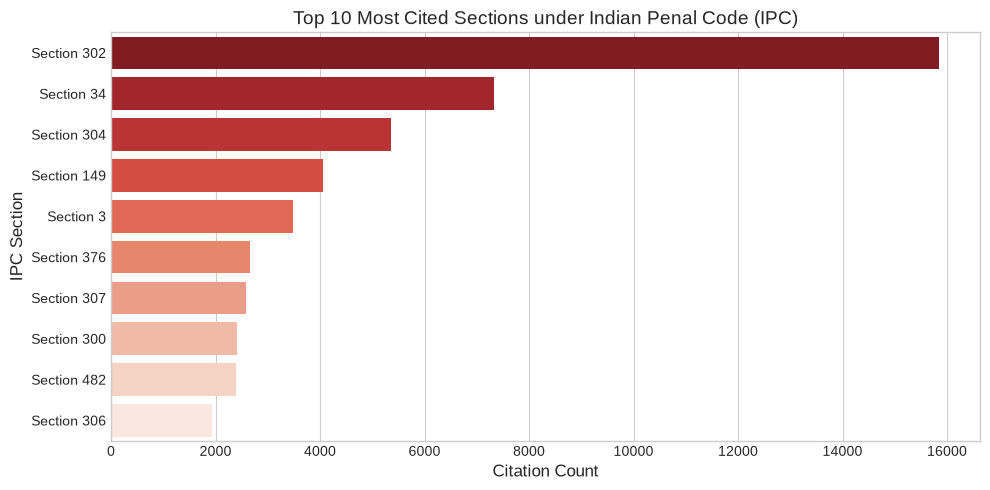

In [4]:
# Top Sections Under Indian Penal Code (IPC)
ipc_sections = con.execute("""
SELECT 
    canonical as section,
    COUNT(*) as count
FROM entities
WHERE type = 'section' AND (statute LIKE '%Indian Penal Code%' OR statute LIKE '%IPC%')
GROUP BY canonical
ORDER BY count DESC
LIMIT 10
""").df()

plt.figure(figsize=(10, 5))
sns.barplot(data=ipc_sections, y='section', x='count', palette='Reds_r')
plt.title('Top 10 Most Cited Sections under Indian Penal Code (IPC)', fontsize=14)
plt.xlabel('Citation Count', fontsize=12)
plt.ylabel('IPC Section', fontsize=12)
plt.tight_layout()
plt.show()

## 2. Statutory Co-Occurrence & Knowledge Graph Edge Mining
Mining which statutes are most frequently cited together in the same judgment.

Top Statutory Co-Citation Pairs across Supreme Court Corpus:


,statute_a,statute_b,co_citation_count
0,From the Judgment and Order,Indian Penal Code,2701
1,Indian Penal Code,"Penal Code, 1860",2101
2,Constitution of India,From the Judgment and Order,1817
3,From the Judgment and Order,"Penal Code, 1860",1568
4,Evidence Act,From the Judgment and Order,991
5,Evidence Act,Indian Penal Code,973
6,Evidence Act,Indian Evidence Act,961
7,Criminal Procedure Code,Indian Penal Code,847
8,Indian Evidence Act,Indian Penal Code,814
9,From the Judgment and Order,Indian Evidence Act,790


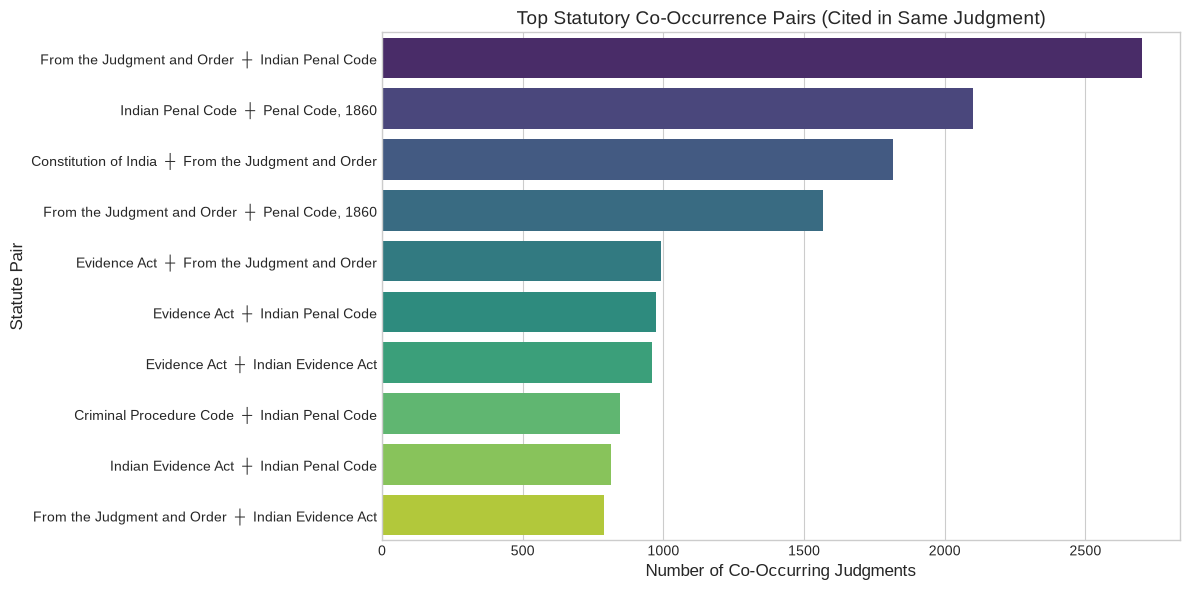

In [6]:
# Find top statute co-occurrences in the same case
co_occurrence_df = con.execute("""
WITH case_statutes AS (
    SELECT DISTINCT case_id, canonical as statute
    FROM entities
    WHERE type = 'statute' AND canonical IS NOT NULL AND canonical != ''
)
SELECT 
    s1.statute as statute_a,
    s2.statute as statute_b,
    COUNT(*) as co_citation_count
FROM case_statutes s1
JOIN case_statutes s2 
    ON s1.case_id = s2.case_id 
   AND s1.statute < s2.statute
GROUP BY s1.statute, s2.statute
ORDER BY co_citation_count DESC
LIMIT 10
""").df()

print('Top Statutory Co-Citation Pairs across Supreme Court Corpus:')
display(co_occurrence_df)

# Plot top co-occurrences
plt.figure(figsize=(12, 6))
pair_labels = co_occurrence_df['statute_a'] + "  ┼  " + co_occurrence_df['statute_b']
sns.barplot(x=co_occurrence_df['co_citation_count'], y=pair_labels, palette='viridis')
plt.title('Top Statutory Co-Occurrence Pairs (Cited in Same Judgment)', fontsize=14)
plt.xlabel('Number of Co-Occurring Judgments', fontsize=12)
plt.ylabel('Statute Pair', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Paragraph Positional & Structural Layout Analytics
Analyzing where different entity types appear across the structural paragraphs of a judgment.

Paragraph Positional Distribution by Entity Type:


,type,avg_paragraph_index,median_paragraph,max_paragraph
0,cnr,4.00,4.0,4
1,neutral_citation,13.53,0.0,503
2,order_rule,20.59,11.0,1228
3,monetary_value,21.00,8.0,1326
4,date,26.31,10.0,1609
5,section,29.33,11.0,1609
6,statute,30.02,10.0,1612
7,annexure,34.09,14.0,1583
8,reporter_citation,34.45,14.0,1540
9,article,88.71,24.0,1612


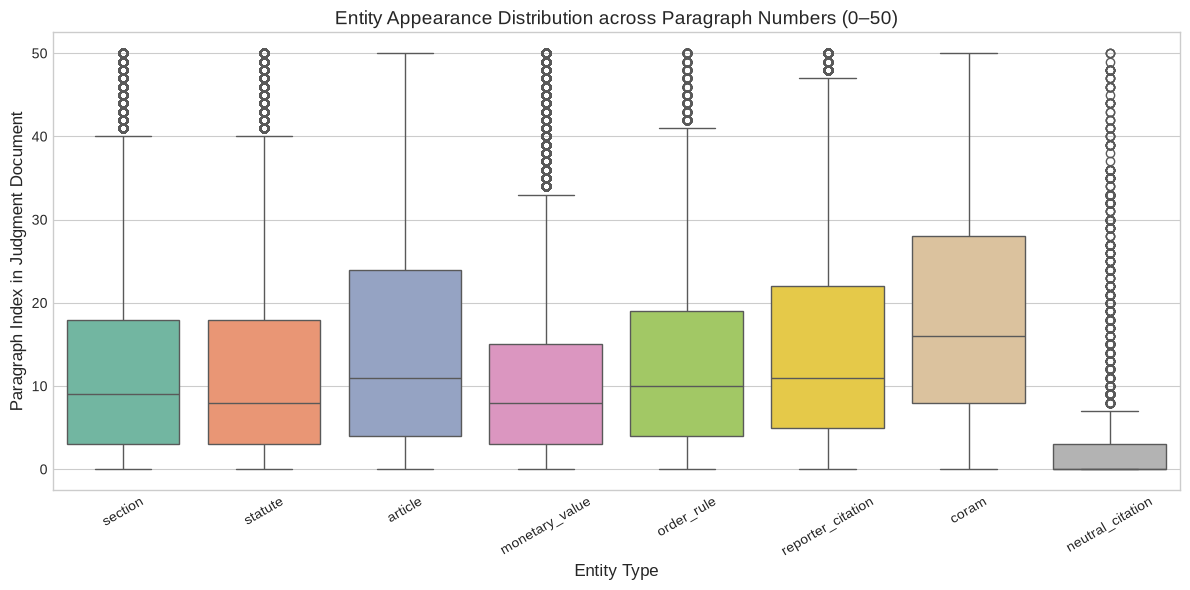

In [8]:
# Paragraph position analysis by entity type
position_df = con.execute("""
SELECT 
    type,
    ROUND(AVG(paragraph), 2) as avg_paragraph_index,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY paragraph) as median_paragraph,
    MAX(paragraph) as max_paragraph
FROM entities
GROUP BY type
ORDER BY avg_paragraph_index ASC
""").df()

print('Paragraph Positional Distribution by Entity Type:')
display(position_df)

# Boxplot of paragraph distribution for key entity types
key_types_df = con.execute("""
SELECT type, paragraph
FROM entities
WHERE type IN ('coram', 'reporter_citation', 'neutral_citation', 'statute', 'section', 'article', 'order_rule', 'monetary_value')
  AND paragraph <= 50
""").df()

plt.figure(figsize=(12, 6))
sns.boxplot(data=key_types_df, x='type', y='paragraph', palette='Set2')
plt.title('Entity Appearance Distribution across Paragraph Numbers (0–50)', fontsize=14)
plt.xlabel('Entity Type', fontsize=12)
plt.ylabel('Paragraph Index in Judgment Document', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Law Reporter Citations & Bench Size Correlation
Analyzing law reporters (SCC, AIR, SCR, SCALE) and bench composition.

In [10]:
# Reporter Citations Frequency
reporters_df = con.execute("""
SELECT 
    canonical as reporter_name,
    COUNT(*) as citation_count
FROM entities
WHERE type = 'reporter_citation' OR type = 'neutral_citation'
GROUP BY canonical
ORDER BY citation_count DESC
LIMIT 10
""").df()

print('Top Citation Reporters:')
display(reporters_df)

# Entity Density vs Bench Size
bench_density_df = con.execute("""
WITH doc_years AS (
    SELECT 
        document_id,
        LEN(bench) as bench_size
    FROM metadata
    WHERE bench IS NOT NULL AND LEN(bench) > 0
),
ent_counts AS (
    SELECT case_id, COUNT(*) as total_entities
    FROM entities
    GROUP BY case_id
)
SELECT 
    dy.bench_size,
    COUNT(DISTINCT dy.document_id) as doc_count,
    ROUND(AVG(ec.total_entities), 2) as avg_entities
FROM doc_years dy
JOIN ent_counts ec ON dy.document_id = ec.case_id
WHERE dy.bench_size <= 7
GROUP BY dy.bench_size
ORDER BY dy.bench_size
""").df()

print('Bench Size vs Entity Extraction Density:')
display(bench_density_df)

Top Citation Reporters:
Bench Size vs Entity Extraction Density:


,reporter_name,citation_count
0,AIR 1952 SC 343,125
1,AIR 1960 SC 866,93
2,AIR 1984 SC 1622,88
3,AIR 1965 SC 202,84
4,AIR 1956 SC 316,79
5,AIR 1954 SC 621,78
6,AIR 1987 SC 350,77
7,AIR 1985 SC 1224,76
8,AIR 1989 SC 1890,76
9,AIR 1955 SC 807,76


,bench_size,doc_count,avg_entities
0,3,2,54.50
1,4,7,52.14
2,5,4,97.50
3,6,4,162.75
4,7,2,75.50


## 5. Extraction Quality & Confidence Audit
Auditing confidence metrics across ~2.89 million records.

In [12]:
# Confidence Quantiles per Entity Type
conf_quantiles = con.execute("""
SELECT 
    type,
    COUNT(*) as count,
    ROUND(MIN(confidence), 2) as min_conf,
    ROUND(QUANTILE_CONT(confidence, 0.25), 2) as q25_conf,
    ROUND(QUANTILE_CONT(confidence, 0.50), 2) as median_conf,
    ROUND(QUANTILE_CONT(confidence, 0.75), 2) as q75_conf,
    ROUND(MAX(confidence), 2) as max_conf
FROM entities
GROUP BY type
ORDER BY median_conf DESC
""").df()

print('Extraction Confidence Score Quantile Audit:')
display(conf_quantiles)

Extraction Confidence Score Quantile Audit:


,type,count,min_conf,q25_conf,median_conf,q75_conf,max_conf
0,cnr,1,1.00,1.00,1.00,1.00,1.00
1,neutral_citation,3961,1.00,1.00,1.00,1.00,1.00
2,reporter_citation,33042,0.95,0.95,0.95,0.95,0.95
3,statute,752628,0.95,0.95,0.95,0.95,0.95
4,article,254464,0.95,0.95,0.95,0.95,0.95
5,annexure,15759,0.90,0.90,0.90,0.90,0.90
6,order_rule,17257,0.90,0.90,0.90,0.90,0.90
7,coram,17072,0.90,0.90,0.90,0.90,0.90
8,section,1040970,0.90,0.90,0.90,0.90,0.90
9,date,585010,0.90,0.90,0.90,0.90,0.90
